**MY FIRST PROJECT**

- Agent that routes requests to one of four nodes:
  - Calculator
  - Greeting
  - Time
  - Chat(default)

**N/B**: The calculator uses eval() for learning purposes and should not be used with untrusted user input in production.

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from datetime import datetime

In [6]:
# create our state which is the schema
# State---> Shared data that flows through every node
class AgentState(TypedDict):
  question: str
  answer: str

In [15]:
# Nodes--> A python function that performs one task
def greeting(state: AgentState)-> AgentState:
  """Greet the user"""
  state['answer']='Hello Allan'

  return state

def check_time(state: AgentState)-> AgentState:
  """Get the Current time"""
  state ['answer']= datetime.now().strftime("%I:%M:%S %p")

  return state

def calculator(state: AgentState)-> AgentState:
  """Perform calculation using eval"""
  try:
    state['answer']=eval(state['question'])
    return state
  except Exception as e:
    state['answer']=f"Error: {e}"
    return state


def chat(state: AgentState)-> AgentState:
  """use this to respond to random user questions"""
  state['answer']="I am not sure I can help with that"

  return state


In [16]:
# Now we write the router to decide what to run
def  decide_next_node(state: AgentState)-> str:
  """Decide the next node we should learn"""
  question=state['question'].lower()

  # Check greeting
  greeting_list=["hi","hello"]
  if question in greeting_list:
    return "greeting"

  # check time
  if "time" in question:
    return "time"

  # calculator
  math_symbols=["+", "-", "/", "*"]
  if any(symbol in question for symbol in math_symbols):
    return "calculator"

  # default
  return "chat"


In [17]:
# now create our graph blueprint
graph=StateGraph(AgentState)

# Add Nodes
graph.add_node("greeting", greeting)
graph.add_node("time", check_time)
graph.add_node("calculator", calculator)
graph.add_node("chat", chat)
graph.add_node("router", lambda state:state) # pass through function

# Edges--> connection that tells the graph what to execute next
graph.add_edge(START, "router")

# add now our condional edge
graph.add_conditional_edges(
    'router',
    decide_next_node,
    {
        "greeting": "greeting",
        "time": "time",
        "calculator": "calculator",
        "chat": "chat",
    }
)

# set END-->Point where execution finishes
graph.add_edge("greeting", END)
graph.add_edge("time", END)
graph.add_edge("calculator", END)
graph.add_edge("chat", END)

# compile our graph blueprint to an executable
app=graph.compile()



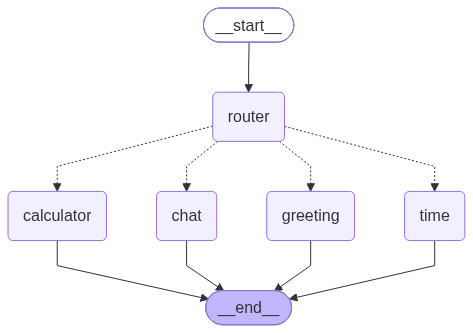

In [18]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
app.invoke({"question":"hello"})

{'question': 'hello', 'answer': 'Hello Allan'}

In [20]:
app.invoke({"question":"1+1"})

{'question': '1+1', 'answer': 2}

In [21]:
app.invoke({"question":"time"})

{'question': 'time', 'answer': '10:20:42 AM'}

In [22]:
app.invoke({"question":"where are we"})

{'question': 'where are we', 'answer': 'I am not sure I can help with that'}

**What We Learned**

1. Defining state
2. Creating Nodes
3. Using Conditional Routing
4. Compiling the graph
5. Running the application with *"invoke"*